# PowerPlant

In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("PowerPlant_Data.csv")

In [3]:
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9568 entries, 0 to 9567
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AT      9568 non-null   float64
 1   V       9568 non-null   float64
 2   AP      9568 non-null   float64
 3   RH      9568 non-null   float64
 4   PE      9568 non-null   float64
dtypes: float64(5)
memory usage: 373.9 KB


,AT,V,AP,RH,PE
count,9568.000000,9568.000000,9568.000000,9568.000000,9568.000000
mean,19.651231,54.305804,1013.259078,73.308978,454.365009
std,7.452473,12.707893,5.938784,14.600269,17.066995
min,1.810000,25.360000,992.890000,25.560000,420.260000
25%,13.510000,41.740000,1009.100000,63.327500,439.750000
50%,20.345000,52.080000,1012.940000,74.975000,451.550000
75%,25.720000,66.540000,1017.260000,84.830000,468.430000
max,37.110000,81.560000,1033.300000,100.160000,495.760000


#### The dataset contains 9568 observations and 5 numerical features:
* AT => temperature
* V => vacuum
* AP => pressure
* RH => humidity
* PE => produved energy

In [6]:
X = df.drop("PE",axis = 1)
y = df["PE"]

In [7]:
y.head()

0    480.48
1    445.75
2    438.76
3    453.09
4    464.43
Name: PE, dtype: float64

### Train-Test-Split + Feature Scaling

In [8]:
# Split out data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [9]:
df.shape

(9568, 5)

In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [11]:
X_train_scaled

array([[ 0.74805289,  0.72006931, -0.32660017, -0.49711722],
       [ 0.86181948,  1.26515721, -0.98521113,  0.8181501 ],
       [ 0.93409473,  1.52314975,  0.32523844,  0.80167494],
       ...,
       [-0.22097078, -0.834965  ,  0.36756563, -0.83554456],
       [ 0.94747903,  1.14245344, -0.41971997, -0.45455637],
       [-1.77355014, -1.19049131,  1.92520594,  0.91837402]])

In [12]:
X_test_scaled

array([[ 1.34499288,  0.23869298, -1.28658067, -1.10532538],
       [ 0.81095912,  1.36269098, -0.74140656,  0.26485915],
       [-0.2437241 , -0.73900436,  1.99970178, -0.19713193],
       ...,
       [-0.67068342, -1.15902881, -0.29951077, -0.10651852],
       [ 1.31420898,  1.33752097, -0.87346737, -0.44288647],
       [-0.2611237 , -0.27021304,  0.37433797,  1.10646548]])

### Tensor Conversion :- TensorDataset and DataLoader

In [15]:
import torch
import torch.nn as nn

X_train_tensor = torch.tensor(X_train_scaled, dtype = torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype = torch.float32).view(-1,1)

X_test_tensor = torch.tensor(X_test_scaled, dtype = torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype = torch.float32).view(-1,1)

In [13]:
type(X_train_scaled)

numpy.ndarray

In [14]:
type(y_train)
y_train.shape

(7654,)

In [16]:
from torch.utils.data import TensorDataset , DataLoader

train_dataset = TensorDataset(X_train_tensor, y_train_tensor) #in_features & out_features
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

In [17]:
train_loader = DataLoader(train_dataset,batch_size = 32, shuffle = True)
test_loader = DataLoader(test_dataset,batch_size = 32)

### Deep Learning

In [30]:
# Build our ANN Model

class ANN(nn.Module):
    def __init__(self):
        super(ANN,self).__init__()

        self.model = nn.Sequential(
            # 1st hidden layer
            nn.Linear(X_train.shape[1], 6), #in_features & out_features
            nn.ReLU(),
            
            # 2nd hidden layer
            nn.Linear(6,6),
            nn.ReLU(),
    
            #output layer
            nn.Linear(6,1),
        )

    def forward(self, x):
        return self.model(x)

In [31]:
import torch.optim as optim

model = ANN()

# loss, optimizer
crietrion = nn.MSELoss()
optimizer = optim.Adam(model.parameters())

In [32]:
# Train the ANN
train_losses = []
val_losses = []

best_val_loss = float("inf")

epochs = 100

for epoch in range(epochs):
    model.train() # Adjuste Weight
    running_loss = 0.0 # tot training loss for 1 epoch
    
    for xb, yb in train_loader:
        # xb = features of 1 batch
        # yb = labels of 1 batch
        optimizer.zero_grad()
        
        outputs = model(xb) # forward prop....predicted outputs for this batch
        loss = crietrion(outputs, yb) # compute loss
        loss.backward() # back prop.. compute gradients
        optimizer.step() # params update
        
        running_loss += loss.item() # loss is a tensor => py float

    epoch_train_loss = running_loss / len(train_loader)
    train_losses.append(epoch_train_loss)


    # Validation
    model.eval()
    running_val_loss = 0.0

    with torch.no_grad(): # no gradients compute
        for xb, yb in test_loader:
            outputs = model(xb)
            loss = crietrion(outputs, yb)
            running_val_loss += loss

    epoch_val_loss = running_val_loss / len(test_loader)
    val_losses.append(epoch_val_loss)

    print(f"epoch {epoch+1}/{epochs} ==> train loss = {epoch_train_loss} & val loss = {epoch_val_loss}")

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(model.state_dict(), "best_model.pt") #.pt or .pth

epoch 1/100 ==> train loss = 206075.8291015625 & val loss = 203961.328125
epoch 2/100 ==> train loss = 198127.8966796875 & val loss = 188719.5
epoch 3/100 ==> train loss = 170998.01555989584 & val loss = 148093.296875
epoch 4/100 ==> train loss = 119415.78850911459 & val loss = 90539.8671875
epoch 5/100 ==> train loss = 66368.14361979166 & val loss = 46991.01171875
epoch 6/100 ==> train loss = 35590.87722981771 & val loss = 28069.849609375
epoch 7/100 ==> train loss = 23872.673453776042 & val loss = 21020.076171875
epoch 8/100 ==> train loss = 18821.95877685547 & val loss = 17084.705078125
epoch 9/100 ==> train loss = 15436.321004231771 & val loss = 13830.87109375
epoch 10/100 ==> train loss = 12269.593670654296 & val loss = 10746.9384765625
epoch 11/100 ==> train loss = 9339.270379638672 & val loss = 7954.0732421875
epoch 12/100 ==> train loss = 6804.841151936849 & val loss = 5741.484375
epoch 13/100 ==> train loss = 4880.186275227865 & val loss = 4087.01171875
epoch 14/100 ==> train 

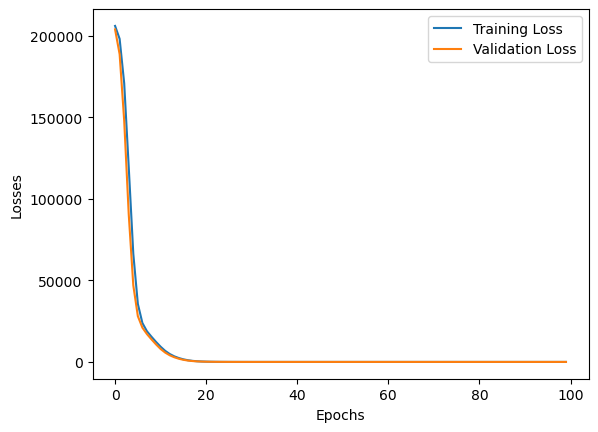

In [33]:
import matplotlib.pyplot as plt

loss_df = pd.DataFrame({
    "Training Loss": train_losses,
    "Validation Loss": val_losses
})

plt.plot(loss_df["Training Loss"], label = "Training Loss")
plt.plot(loss_df["Validation Loss"], label = "Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Losses")

plt.legend()

In [34]:
# Loading the best model
model.load_state_dict(torch.load("best_model.pt"))

<All keys matched successfully>

### Evaluate Model

In [36]:
# Evaluation

model.eval()
with torch.no_grad():
    train_preds = model(X_train_tensor)
    test_preds = model(X_test_tensor)

    train_mse_loss = crietrion(train_preds, y_train_tensor)
    test_mse_loss = crietrion(test_preds, y_test_tensor)

print("Training MSE:", train_mse_loss.item())
print("Testing MSE:", test_mse_loss.item())

Training MSE: 20.375125885009766
Testing MSE: 18.781997680664062


In [40]:
from sklearn.metrics import r2_score

print("r^2 score = ",r2_score(y_test,test_preds))

r^2 score =  0.9343617685047862


In [42]:
predicted_df = pd.DataFrame(test_preds.numpy(), columns=["Predicted Values"])
actual_df = pd.DataFrame(y_test.values, columns=["Actual Values"])

pd.concat([predicted_df, actual_df], axis=1)

,Predicted Values,Actual Values
0,435.422699,433.27
1,437.024078,438.16
2,461.394440,458.42
3,476.347137,480.82
4,435.415985,441.41
...,...,...
1909,451.484833,456.70
1910,431.754730,438.04
1911,467.748627,467.80
1912,431.174835,437.14
